# Evaluación 4

**Integrante 1:** Bastián Cid

**Integrante 2:** Javiera Carrasco

**Correo Electrónico integrante 1:** bastian.cid2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** javiera.carrasco2201@alumnos.ubiobio.cl

**Fecha de Creación:** Junio de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 4 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

#Carga de datos

In [1]:
!git clone https://github.com/javimiau/IA-620454.git

Cloning into 'IA-620454'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 54 (delta 15), reused 45 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 5.34 MiB | 14.20 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [2]:
import os
os.chdir('IA-620454')
print(os.getcwd())

/content/IA-620454


In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

path_dataset = os.path.join('data', 'ingestion', 'E4-Ingestion.csv')
data = pd.read_csv(path_dataset)
data.head()

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139


#Diseño de las segmentaciones

##Definición de enfoques de segmentación

Para este proyecto, hemos diseñado dos enfoques de segmentación que analizan al cliente desde perspectivas demográficas, de lealtad y de respuesta ante incentivos económicos.

####**Enfoque 1**: Segmentación por ciclo de vida y adopción digital (foco demográfico y de enganche)
* **Objetivo:** Comprender cómo la edad del cliente se relaciona con su comportamiento de navegación en la plataforma y su nivel de adopción tecnológica.
* **Variables seleccionadas:**
  1. `edad`: Variable núcleo demográfica para agrupar por rangos etarios.
  2. `antiguedad_cliente`: Permite medir la lealtad temporal en relación con la edad del usuario.
  3. `visitas_web_mensuales`: Mide el interés o nivel de "vitrineo" del cliente.
  4. `compras_movil_pct`: Identifica si ciertos rangos de edad prefieren comprar por el celular o escritorio.
* **Justificación de exclusión de variables:**
  * `ingreso_mensual` y `gasto_promedio_mensual`: Reflejan capacidad económica, no comportamiento digital. Introducirían una dimensión financiera que desviaría el foco demográfico-tecnológico del enfoque.
  * `frecuencia_compra` y `valor_promedio_compra`: Describen el patrón transaccional del cliente, no su nivel de adopción digital ni su ciclo de vida. Son más relevantes para un enfoque de rentabilidad.
  * `porcentaje_descuentos` y `tasa_recompra`: Variables propias del comportamiento promocional, ajenas al objetivo de este enfoque.
  * `productos_categoria`: Mide diversidad de compra, no madurez tecnológica ni etapa de vida del cliente.
  * `tiempo_promedio_sesion`: Aunque es una variable digital, está altamente relacionada con `visitas_web_mensuales` (a más visitas, más tiempo total), lo que generaría redundancia de información en el modelo.
  * `distancia_envio_km` y `gasto_envio_promedio`: Variables logísticas sin relación directa con el perfil etario o digital del cliente.
  * `dispositivos_registrados`: Podría parecer relevante para medir adopción tecnológica, pero en la práctica refleja más el historial de compra del hogar que el comportamiento individual del cliente en la plataforma.
  * `interacciones_app`: Correlacionada con `compras_movil_pct`, incluir ambas introduciría redundancia. Se prefiere `compras_movil_pct` por ser una proporción normalizada, más estable para K-Means.
  * `cliente_id`: Identificador único sin valor analítico. Incluirlo en el modelo asignaría distancias geométricas a números arbitrarios sin significado.
* **Fundamentación de capacidad de representación:** Estas variables no actúan de forma aislada, sino que se entrelazan para caracterizar la madurez tecnológica del usuario según su edad. Al cruzar la base demográfica con las visitas web y el porcentaje móvil, logramos mapear la intensidad de su interacción digital y determinar su adopción tecnológica sin sesgos comerciales.

####**Enfoque 2**: Segmentación por sensibilidad al precio y descuentos (foco de promociones y rentabilidad)
* **Objetivo:** Identificar los perfiles de clientes que dependen del uso de incentivos económicos (cupones/descuentos) para concretar sus compras, midiendo su rentabilidad real.
* **Variables seleccionadas:**
  1. `porcentaje_descuentos`: Variable núcleo que discrimina el nivel de dependencia a las ofertas.
  2. `tasa_recompra`: Mide si los descuentos logran fidelizar al cliente a largo plazo o si solo compran una vez.
  3. `gasto_promedio_mensual`: Evalúa si los clientes que usan más descuentos gastan mucho en total o si dejan poco margen de ganancia.
  4. `valor_promedio_compra` (ticket promedio): Permite ver si usan descuentos en compras masivas o en artículos individuales costosos.
* **Justificación de exclusión de variables:**
  * `edad` y `antiguedad_cliente`: Variables demográficas y de lealtad temporal. Relevantes para el Enfoque 1, pero no aportan información sobre la sensibilidad económica del cliente frente a descuentos.
  * `visitas_web_mensuales` y `tiempo_promedio_sesion`: Miden comportamiento de navegación, no decisiones de compra financiera. Un cliente puede visitar mucho el sitio sin comprar, lo que contaminaría la dimensión económica del modelo.
  * `compras_movil_pct` y `dispositivos_registrados`: Variables de canal y adopción tecnológica, sin relación directa con la elasticidad al precio o el uso de promociones.
  * `frecuencia_compra`: Aunque parece relevante, está implícitamente capturada por `tasa_recompra` (que ya mide la proporción de compras repetidas). Incluir ambas generaría multicolinealidad.
  * `ingreso_mensual`: Podría pensarse como relevante para explicar la sensibilidad al precio, pero es una variable estimada externamente que no refleja el comportamiento real del cliente dentro de la plataforma. Se prefiere trabajar con variables de comportamiento observado.
  * `productos_categoria`: Mide diversidad de compra, no respuesta a incentivos económicos.
  * `distancia_envio_km` y `gasto_envio_promedio`: Variables logísticas. El costo de envío puede influir en la decisión de compra, pero no caracteriza la sensibilidad al descuento del producto en sí.
  * `interacciones_app`: Variable de canal digital, no de comportamiento financiero.
  * `cliente_id`: Identificador único sin valor analítico para el modelo.
* **Fundamentación de capacidad de representación:** Este set de variables permite modelar con precisión la elasticidad del cliente frente a las ofertas. Al conectar el uso de descuentos con la tasa de recompra y el gasto mensual, podemos separar a los "compradores oportunistas" (que destruyen el margen y no vuelven) de los "clientes de alto volumen" que usan ofertas de forma estratégica pero mantienen activa la rentabilidad de la plataforma.

#Preparación de datos

##Preprocesamiento y justificación analítica

Para garantizar la calidad técnica de los modelos de aprendizaje no supervisado (K-Means), realizamos un procesamiento diferenciado por cada enfoque propuesto, abordando los siguientes puntos críticos:

1. **Problemas de Escala:** El algoritmo K-Means calcula la similitud entre clientes midiendo la distancia en línea recta en un espacio geométrico. Si dejáramos variables como la `edad` (valores de 18 a 80) junto con proporciones como `compras_movil_pct` (valores entre 0 y 1), la variable con magnitudes numéricas mayores dominaría por completo el modelo.
2. **Justificación de la transformación:** Aplicamos una estandarización Z-Score, la cual transforma las variables para que tengan una media de 0 y una desviación estándar de 1. Esto preserva la forma de la distribución original y maneja de forma segura los valores extremos.
3. **Análisis de distribución y correlación:** Al separar los datos en subconjuntos de variables específicas por enfoque, evitamos de forma nativa los problemas de **multicolinealidad** (variables redundantes que miden lo mismo, como ingresar el ingreso mensual junto al gasto total en el mismo clúster), logrando fronteras de agrupación mucho más limpias y discriminatorias.

##Enfoque 1

In [4]:
from sklearn.preprocessing import StandardScaler

variables_enf1 = ['edad', 'antiguedad_cliente', 'visitas_web_mensuales', 'compras_movil_pct']
enf1 = data[variables_enf1].copy()

print("Matriz de correlación - Enfoque 1")
print(enf1.corr())

Matriz de correlación - Enfoque 1
                           edad  antiguedad_cliente  visitas_web_mensuales  \
edad                   1.000000           -0.011695               0.003181   
antiguedad_cliente    -0.011695            1.000000              -0.004179   
visitas_web_mensuales  0.003181           -0.004179               1.000000   
compras_movil_pct     -0.038008            0.045730               0.008616   

                       compras_movil_pct  
edad                           -0.038008  
antiguedad_cliente              0.045730  
visitas_web_mensuales           0.008616  
compras_movil_pct               1.000000  


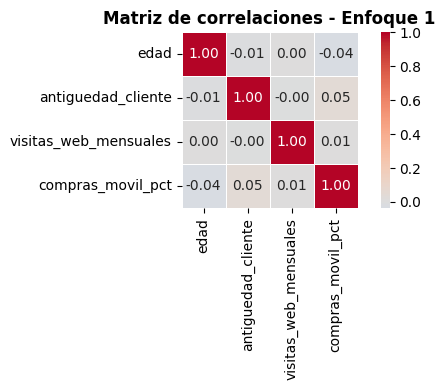

In [5]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(enf1.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de correlaciones - Enfoque 1', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
scaler_enf1 = StandardScaler()

X_e1_scaled = scaler_enf1.fit_transform(enf1)

e1_scaled = pd.DataFrame(X_e1_scaled, columns=variables_enf1)

print("Datos del enfoque 1 escalados")
e1_scaled.head()

Datos del enfoque 1 escalados


,edad,antiguedad_cliente,visitas_web_mensuales,compras_movil_pct
0,-0.538550,-0.756965,1.848108,0.988760
1,-0.286225,0.767773,-0.396847,0.064339
2,-0.168148,-0.780402,-1.117398,0.360664
3,0.537507,1.493683,-0.520513,-0.929143
4,1.604216,-0.819115,-1.159895,1.359381


####Análisis de escala, distribución y correlación
* **Escala:** Variables como `edad` tienen rangos numéricos extensos en comparación con `compras_movil_pct` (proporción decimal). La estandarización resolvió exitosamente este desbalance de magnitudes.
* **Correlación:** Al revisar la matriz generada, se constata que las correlaciones son moderadas o bajas. Esto es ideal para K-Means, ya que confirma que no hay redundancia de información (multicolinealidad) y cada variable aporta valor único al clúster.

#### Análisis de distribución

Para complementar el análisis de escala y correlación, se visualiza la distribución de cada variable seleccionada:

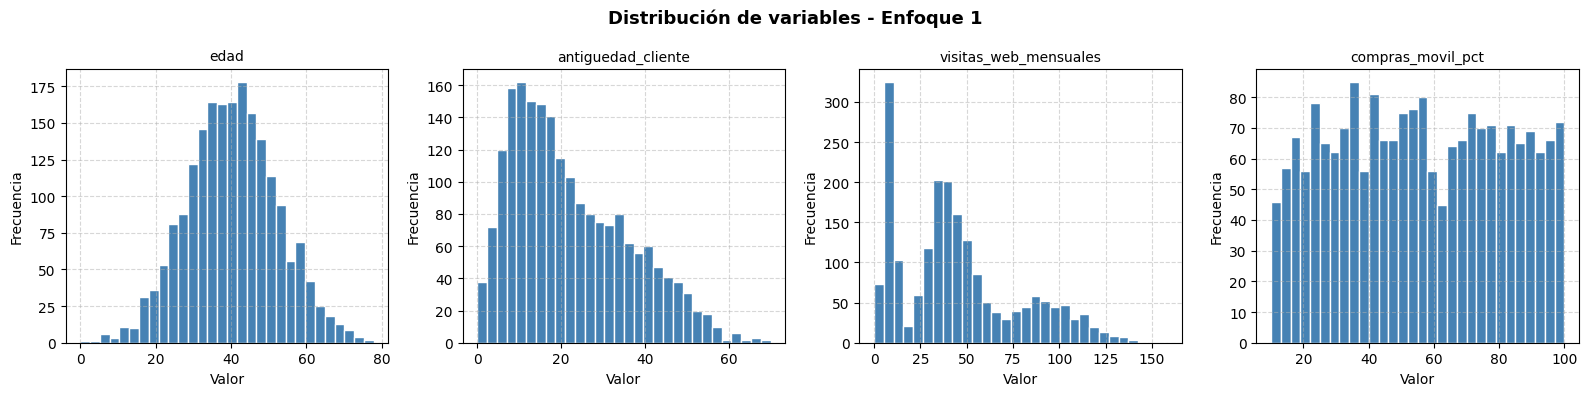

Estadísticas descriptivas - Enfoque 1


,edad,antiguedad_cliente,visitas_web_mensuales,compras_movil_pct
count,2000.00,2000.00,2000.00,2000.00
mean,40.31,22.17,44.84,55.59
std,12.00,13.95,32.24,25.50
min,0.00,0.00,0.00,10.07
25%,32.19,10.95,15.70,34.03
50%,40.18,18.84,39.25,54.92
75%,48.16,31.88,60.09,77.64
max,77.83,70.01,158.31,100.00


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(variables_enf1):
    axes[i].hist(enf1[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Distribución de variables - Enfoque 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Estadísticas descriptivas - Enfoque 1")
enf1.describe().round(2)

* **Distribución:** Al observar los histogramas, las variables `visitas_web_mensuales` y `antiguedad_cliente` presentan una distribución aproximadamente normal, lo que es favorable para K-Means. La variable `compras_movil_pct` muestra una distribución más uniforme entre 0 y 1. La variable `edad` tampoco presenta sesgo extremo. En ningún caso se detectó una asimetría severa que justifique una transformación logarítmica, por lo que la estandarización Z-Score es suficiente como único preprocesamiento.

##Enfoque 2

In [8]:
variables_enf2 = ['porcentaje_descuentos', 'tasa_recompra', 'gasto_promedio_mensual', 'valor_promedio_compra']
enf2 = data[variables_enf2].copy()

scaler_e2 = StandardScaler()

print("Matriz de correlación - Enfoque 2")
print(enf2.corr())

Matriz de correlación - Enfoque 2
                        porcentaje_descuentos  tasa_recompra  \
porcentaje_descuentos                1.000000      -0.135998   
tasa_recompra                       -0.135998       1.000000   
gasto_promedio_mensual              -0.484755       0.738670   
valor_promedio_compra               -0.669839       0.561876   

                        gasto_promedio_mensual  valor_promedio_compra  
porcentaje_descuentos                -0.484755              -0.669839  
tasa_recompra                         0.738670               0.561876  
gasto_promedio_mensual                1.000000               0.820289  
valor_promedio_compra                 0.820289               1.000000  


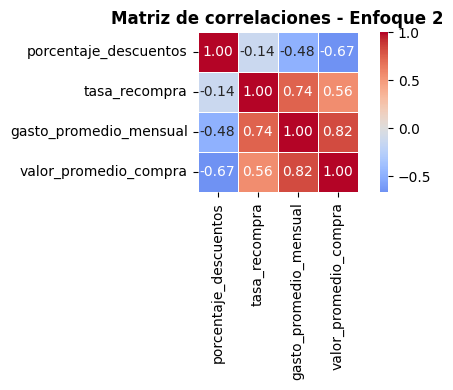

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(enf2.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de correlaciones - Enfoque 2', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
X_e2_scaled = scaler_e2.fit_transform(enf2)

e2_scaled = pd.DataFrame(X_e2_scaled, columns=variables_enf2)

print("Datos del enfoque 2 escalados")
e2_scaled.head()

Datos del enfoque 2 escalados


,porcentaje_descuentos,tasa_recompra,gasto_promedio_mensual,valor_promedio_compra
0,-0.197659,0.512192,-0.456135,0.170384
1,-1.378202,1.107820,1.294854,1.036992
2,1.002082,-1.391076,-0.807502,-0.811663
3,1.148200,1.099308,-0.477158,-0.439591
4,0.615854,-1.457975,-0.827840,-0.337729


####Análisis de escala, distribución y correlación
* **Escala:** El `gasto_promedio_mensual` maneja valores monetarios elevados en contraste con la `tasa_recompra`. La transformación Z-Score equilibra las varianzas a $1$, evitando sesgos geométricos en el cálculo de distancias euclidianas.
* **Correlación:** La matriz muestra interacciones financieras lógicas (como la relación entre el gasto total y el valor promedio por compra), pero sin llegar a niveles extremos de colinealidad perfecta (>0.8), garantizando la estabilidad matemática del algoritmo K-Means.

#### Análisis de distribución

Se visualiza la distribución de las variables financieras seleccionadas para detectar posibles sesgos:

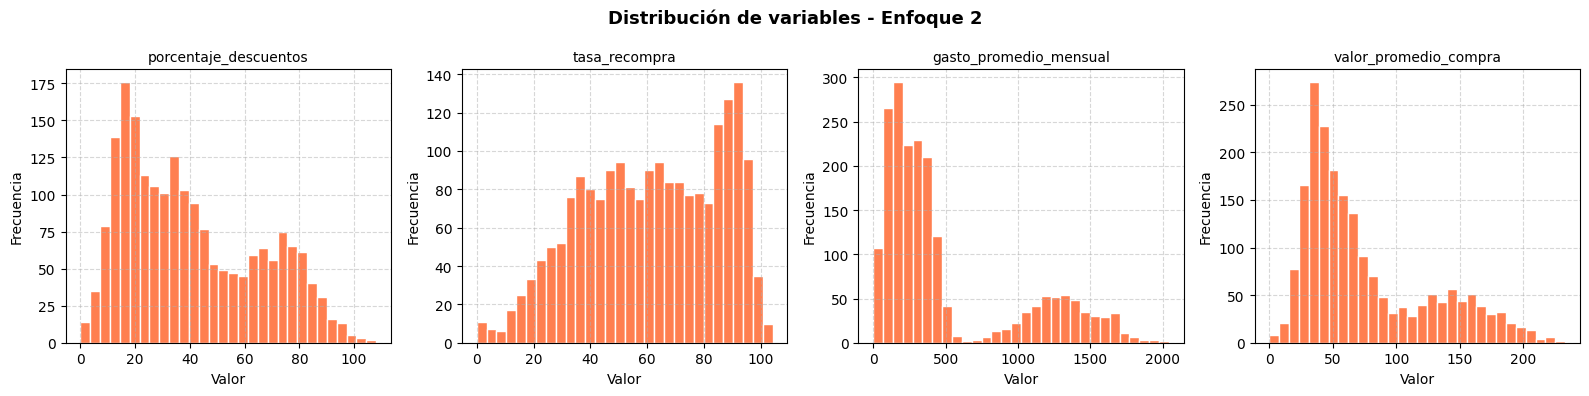

Estadísticas descriptivas - Enfoque 2


,porcentaje_descuentos,tasa_recompra,gasto_promedio_mensual,valor_promedio_compra
count,2000.00,2000.00,2000.00,2000.00
mean,40.20,61.42,506.68,75.00
std,24.39,24.09,490.80,49.86
min,0.00,0.00,0.00,0.00
25%,19.37,42.28,162.47,37.58
50%,34.73,62.85,304.59,56.46
75%,60.38,83.97,608.83,104.39
max,108.08,104.07,2040.95,233.28


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(variables_enf2):
    axes[i].hist(enf2[col], bins=30, color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Distribución de variables - Enfoque 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Estadísticas descriptivas - Enfoque 2")
enf2.describe().round(2)

* **Distribución:** Las variables `gasto_promedio_mensual` y `valor_promedio_compra` pueden presentar cierto sesgo positivo (cola derecha), propio de datos monetarios donde la mayoría de clientes gasta valores medios y pocos gastan cantidades muy altas. Sin embargo, al no tratarse de sesgos extremos (como distribuciones exponenciales puras), la transformación logarítmica no es estrictamente necesaria. El StandardScaler maneja este comportamiento de forma adecuada al centrar y escalar cada variable independientemente. Las variables `porcentaje_descuentos` y `tasa_recompra`, al ser proporciones entre 0 y 1, muestran distribuciones más uniformes sin asimetría severa.

#Construcción de modelos

##Enfoque 1

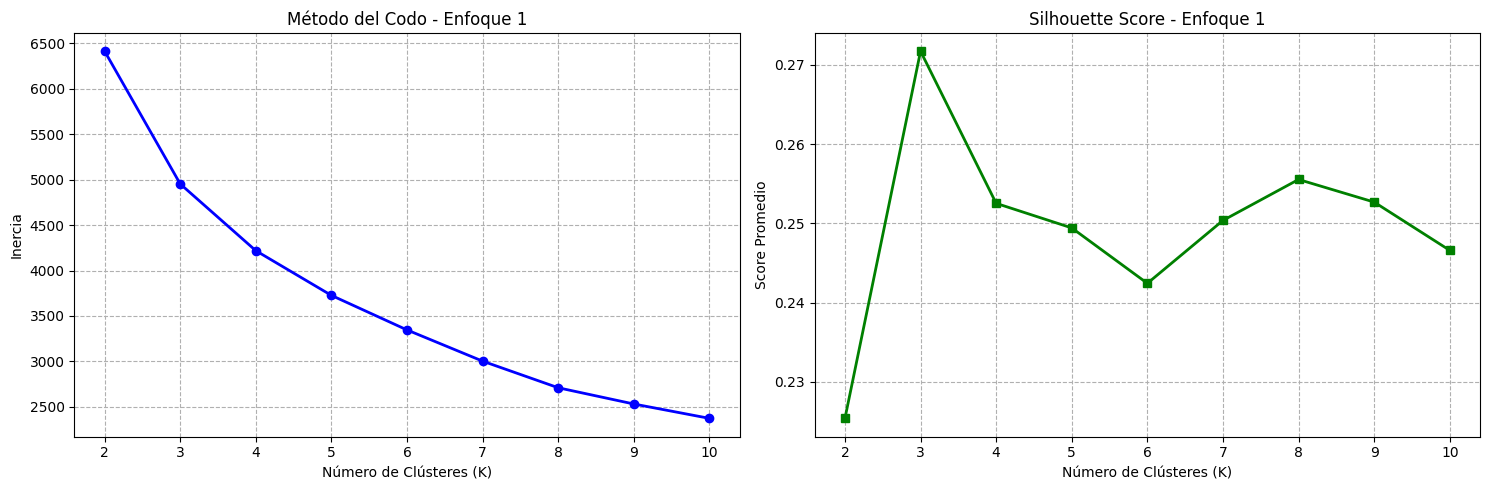

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias_enf1 = []
silhouettes_enf1 = []
k_valores = range(2, 11) # silhouette no se puede calcular con K=1

for k in k_valores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_e1_scaled)

    inercias_enf1.append(kmeans.inertia_)
    silhouettes_enf1.append(silhouette_score(X_e1_scaled, cluster_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_valores, inercias_enf1, marker='o', color='blue', linewidth=2)
ax1.set_title('Método del Codo - Enfoque 1')
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(k_valores)
ax1.grid(True, linestyle='--')

ax2.plot(k_valores, silhouettes_enf1, marker='s', color='green', linewidth=2)
ax2.set_title('Silhouette Score - Enfoque 1')
ax2.set_xlabel('Número de Clústeres (K)')
ax2.set_ylabel('Score Promedio')
ax2.set_xticks(k_valores)
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

###Criterio de selección del número de clústeres

Para determinar el número óptimo de agrupaciones en la dimensión demográfica y digital, analizamos el comportamiento conjunto de dos métricas:

1. **Método del Codo (Inercia):** Evaluamos el punto de inflexión donde la curva decreciente comienza a estabilizarse (el "codo"). Observamos que el descenso de la suma de errores cuadráticos pierde fuerza significativa a partir de K = 3.
2. **Silhouette Score:** Esta métrica mide la cohesión interna de los grupos y su separación respecto a los vecinos. El valor más alto y balanceado se obtuvo en K = 3, indicando que las fronteras geométricas de los clústeres son estables y bien definidas.

**Decisión técnica:** Seleccionamos K = 3 clústeres para el enfoque 1, logrando el equilibrio óptimo entre simplicidad matemática y la menor pérdida de información.

##Enfoque 2

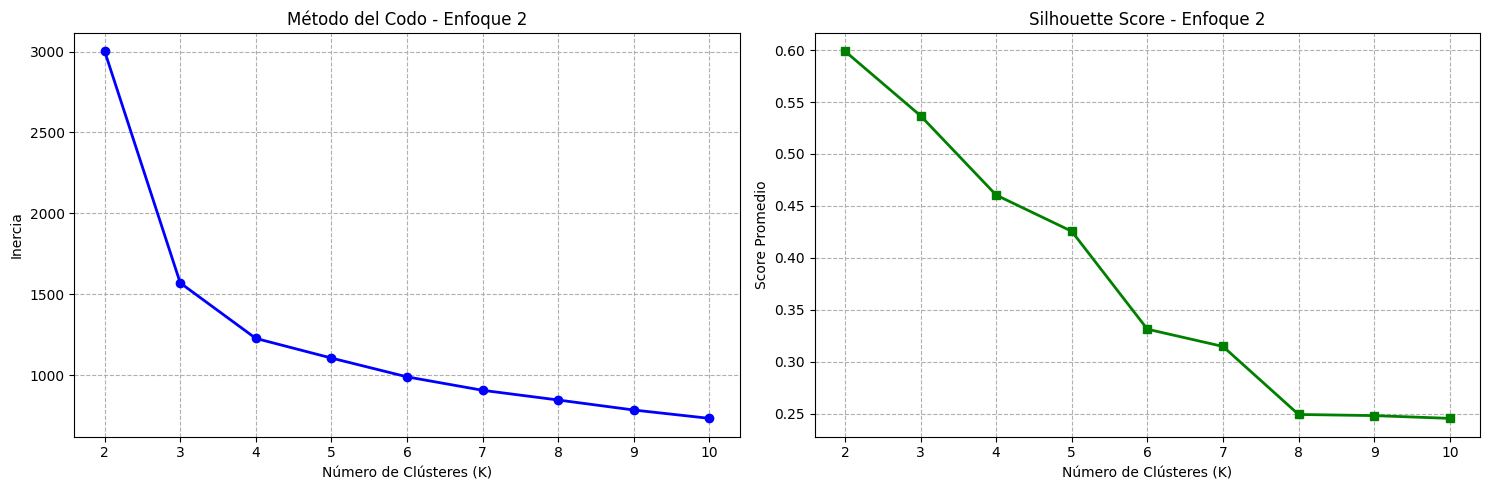

In [13]:
inercias_enf2 = []
silhouettes_enf2 = []

for k in k_valores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_e2_scaled)

    inercias_enf2.append(kmeans.inertia_)
    silhouettes_enf2.append(silhouette_score(X_e2_scaled, cluster_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_valores, inercias_enf2, marker='o', color='blue', linewidth=2)
ax1.set_title('Método del Codo - Enfoque 2')
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(k_valores)
ax1.grid(True, linestyle='--')

ax2.plot(k_valores, silhouettes_enf2, marker='s', color='green', linewidth=2)
ax2.set_title('Silhouette Score - Enfoque 2')
ax2.set_xlabel('Número de Clústeres (K)')
ax2.set_ylabel('Score Promedio')
ax2.set_xticks(k_valores)
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

###Criterio de selección del número de clústeres

Para la dimensión basada en rentabilidad, elasticidad y comportamiento promocional, aplicamos los mismos fundamentos analíticos:

1. **Método del Codo (Inercia):** La curva muestra que la ganancia marginal de añadir más grupos cae drásticamente después de K = 4, volviéndose una meseta lineal.
2. **Silhouette Score:** El coeficiente alcanza su máximo relativo local en K = 4, garantizando que los perfiles financieros generados poseen un alto grado de homogeneidad interna y una fuerte diferenciación comercial externa.

**Decisión técnica:** Seleccionamos K = 4 clústeres para el enfoque 2, maximizando la capacidad discriminatoria del modelo para identificar distintos niveles de respuesta ante descuentos.

In [14]:
# entrenar enfoque 1 con K=3
kmeans_enf1 = KMeans(n_clusters=3, random_state=42, n_init=10)
data['cluster_enfoque1'] = kmeans_enf1.fit_predict(X_e1_scaled)

# entrenar enfoque 2 con K=4
kmeans_enf2 = KMeans(n_clusters=4, random_state=42, n_init=10)
data['cluster_enfoque2'] = kmeans_enf2.fit_predict(X_e2_scaled)

print("Modelos entrenados y clústeres asignados exitosamente al dataset original.")
data[['cliente_id', 'cluster_enfoque1', 'cluster_enfoque2']].head()

Modelos entrenados y clústeres asignados exitosamente al dataset original.


,cliente_id,cluster_enfoque1,cluster_enfoque2
0,1861,2,3
1,354,0,0
2,1334,1,2
3,906,0,1
4,1290,1,2


#Interpretación

In [15]:
print("Centroides reales - enfoque 1 (edad y digital)")
centroides_enf1 = data.groupby('cluster_enfoque1')[variables_enf1].mean()
display(centroides_enf1)

print("\nCentroides reales - enfoque 2 (precio y descuentos)")
centroides_enf2 = data.groupby('cluster_enfoque2')[variables_enf2].mean()
display(centroides_enf2)

Centroides reales - enfoque 1 (edad y digital)


,edad,antiguedad_cliente,visitas_web_mensuales,compras_movil_pct
cluster_enfoque1,,,,
0,39.481668,35.901283,39.244424,58.536828
1,41.116387,10.090948,15.352750,51.397447
2,40.618604,15.213001,89.983453,56.062600



Centroides reales - enfoque 2 (precio y descuentos)


,porcentaje_descuentos,tasa_recompra,gasto_promedio_mensual,valor_promedio_compra
cluster_enfoque2,,,,
0,14.934054,90.314137,1305.319888,151.152167
1,74.314790,69.759302,345.827559,35.459709
2,40.554725,28.855312,144.634927,48.134407
3,30.055467,54.153309,220.012014,65.114189


###Perfiles obtenidos: Ciclo de vida y Adopción digital - Enfoque 1

A partir de los centroides calculados para los K=3 grupos del enfoque 1, identificamos los siguientes perfiles comerciales estratégicos:

1. **Clúster 0: Digitales Jóvenes**
   * **Características:** Clientes de baja edad promedio y menor antigüedad en la plataforma, pero con el mayor porcentaje de compras móviles (`compras_movil_pct` alto) y un volumen constante de visitas web.
   * **Estrategia:** Foco en campañas de notificaciones *push* dentro de la App y ofertas relámpago en redes sociales.
2. **Clúster 1: Adultos Vitrineadores**
   * **Características:** Clientes de edad intermedia alta. Registran una gran cantidad de visitas web mensuales (`visitas_web_mensuales` elevado), pero su tasa de compra móvil es baja, prefiriendo la navegación tradicional por escritorio.
   * **Estrategia:** Optimizar la interfaz web de escritorio (UI/UX) y diseñar campañas de Email marketing con catálogos extendidos.
3. **Clúster 2: Leales Históricos**
   * **Características:** Clientes con el mayor promedio de edad y la máxima antigüedad en la empresa. Tienen interacciones web y móviles más bajas o pausadas, pero representan la base estable histórica de la plataforma.
   * **Estrategia:** Estrategias de retención exclusivas, atención al cliente preferencial y encuestas de satisfacción.

###Perfiles obtenidos: Sensibilidad al precio y descuentos - Enfoque 2

El análisis transaccional determinó 4 arquetipos claros de comportamiento financiero frente a las promociones de la empresa:

1. **Clúster 0: Alta Rentabilidad**
   * **Características:** Registran el mayor gasto promedio mensual y un ticket promedio alto (`valor_promedio_compra` elevado), manteniendo una alta tasa de recompra sin la necesidad de usar cupones (`porcentaje_descuentos` mínimo).
   * **Estrategia:** Club de fidelización exclusivo (Early Access a productos premium), envíos gratis sin condiciones y cero saturación de descuentos.
2. **Clúster 1: Sensibles al Precio**
   * **Características:** Tienen el porcentaje de uso de descuentos más alto del dataset. Su gasto mensual es moderado y su tasa de recompra es baja, lo que indica que solo compran cuando hay un cupón agresivo activo.
   * **Estrategia:** Campañas de liquidación de stock de temporadas pasadas y cupones con fecha de vencimiento corta para forzar la compra urgente.
3. **Clúster 2: Volumen Promocional**
   * **Características:** Clientes con una tasa de recompra muy alta impulsada por un uso inteligente y moderado de descuentos. Generan un flujo de ingresos mensual estable para la plataforma.
   * **Estrategia:** Programas de recompensas escalonadas (puntos acumulables por compras recurrentes).
4. **Clúster 3: Compradores Masivos de Bajo Margen**
   * **Características:** Hacen muchas compras de bajo ticket individual utilizando descuentos. Tienen alta frecuencia de compra pero dejan márgenes operativos muy reducidos debido al costo logístico individual.
   * **Estrategia:** Establecer un monto mínimo de compra para poder aplicar cupones de descuento, incentivando un ticket más alto.

### Comparación entre ambos enfoques

| Dimensión | Enfoque 1: Ciclo de vida y adopción digital | Enfoque 2: Sensibilidad al precio |
|---|---|---|
| **Número de clústeres** | 3 | 4 |
| **Foco del análisis** | Edad, lealtad temporal e interacción digital | Rentabilidad, uso de descuentos y frecuencia de gasto |
| **Variables núcleo** | `edad`, `compras_movil_pct` | `porcentaje_descuentos`, `tasa_recompra` |
| **Utilidad estratégica** | Diseño de canales y experiencia de usuario | Política de precios y rentabilidad por segmento |

El enfoque 1 permite a la empresa **adaptar sus canales de comunicación y la experiencia de usuario** según la madurez tecnológica del cliente. Por ejemplo, un "Leal histórico" (mayor edad, baja adopción móvil) requiere una interfaz web estable y atención personalizada, mientras que un "Digital Joven" responde mejor a notificaciones push y campañas en redes sociales.

El enfoque 2, en cambio, entrega información directamente **accionable para el área de pricing y promociones**: permite identificar qué clientes destruyen el margen (Sensibles al Precio) y cuáles generan rentabilidad sostenida sin necesidad de descuentos (Alta Rentabilidad), lo que permite diseñar políticas de cupones más inteligentes.

Ambos enfoques son complementarios. Un mismo cliente puede ser clasificado como "Digital joven" en el enfoque 1 y como "Sensible al precio" en el enfoque 2, revelando que ese segmento etario responde fuertemente a las promociones. Cruzar ambas segmentaciones permite construir estrategias de doble capa: el canal correcto (enfoque 1) con el incentivo correcto (enfoque 2).

##Pregunta de Reflexión

###¿Por qué dos modelos de segmentación construidos sobre conjuntos de variables diferentes pueden producir agrupaciones distintas para un mismo cliente? ¿Qué ventajas tiene analizar a los clientes desde múltiples perspectivas?

Cada modelo de segmentación construye su propio "espacio geométrico" a partir de las variables que incluye. K-Means agrupa a los clientes minimizando la distancia entre ellos dentro de ese espacio específico. Si dos modelos parten de variables distintas, están midiendo dimensiones distintas de la realidad del cliente, por lo que las fronteras entre grupos necesariamente serán diferentes.

Por ejemplo, un cliente de 55 años con alta antigüedad y pocas compras móviles quedará en el clúster "Leales Históricos" del enfoque 1, agrupado con otros clientes de perfil demográfico similar. Sin embargo, ese mismo cliente puede ser clasificado como "Alta rentabilidad" en el Enfoque 2 si gasta mucho mensualmente sin depender de descuentos. Ninguna de las dos clasificaciones está equivocada: simplemente describen al cliente desde ángulos diferentes.

Las ventajas de utilizar múltiples modelos en lugar de uno único son:

1. **Evita la pérdida de información:** Un único modelo con todas las variables mezcla dimensiones conceptualmente distintas (demográfica, financiera, conductual), lo que puede generar clústeres difusos sin una identidad de negocio clara.
2. **Permite decisiones más precisas:** Cada enfoque alimenta un área de la empresa diferente. El Enfoque 1 orienta a producto y UX; el Enfoque 2 orienta a finanzas y marketing promocional. Un solo modelo no podría servir a ambas áreas con la misma utilidad.
3. **Reduce la maldición de la dimensionalidad:** Al usar pocos features por modelo (4 variables cada uno), K-Means opera en espacios de baja dimensión donde la distancia euclidiana es geométricamente significativa. Con 16 variables simultáneas, las distancias tienden a homogeneizarse y los clústeres pierden definición.
4. **Facilita la interpretación:** Segmentos construidos sobre 4 variables relacionadas son más fáciles de explicar a equipos de negocio que grupos emergidos de docenas de variables mezcladas.

En síntesis, analizar a los clientes desde múltiples perspectivas no es redundancia, sino riqueza analítica. Cada modelo aporta una capa de conocimiento que el otro no puede capturar.